In [2]:
%run data_analysis.ipynb
%run incident_analysis.py


ModuleNotFoundError: No module named 'scipy'

### Visualisation code:

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

analysis = SocialMediaAnalysis()

Password change habits:

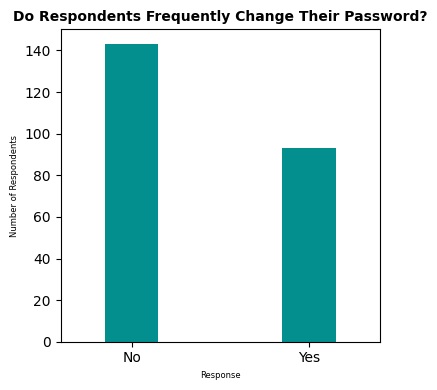

In [4]:
password_changes = analysis.password_change_summary()

plt.figure(figsize=(4, 4))

password_changes.plot(kind="bar", color="#048F8F", legend=False, width=0.3)

plt.title("Do Respondents Frequently Change Their Password?",fontsize=10, fontweight="bold")
plt.xlabel("Response", fontsize=6)
plt.ylabel("Number of Respondents", fontsize=6)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

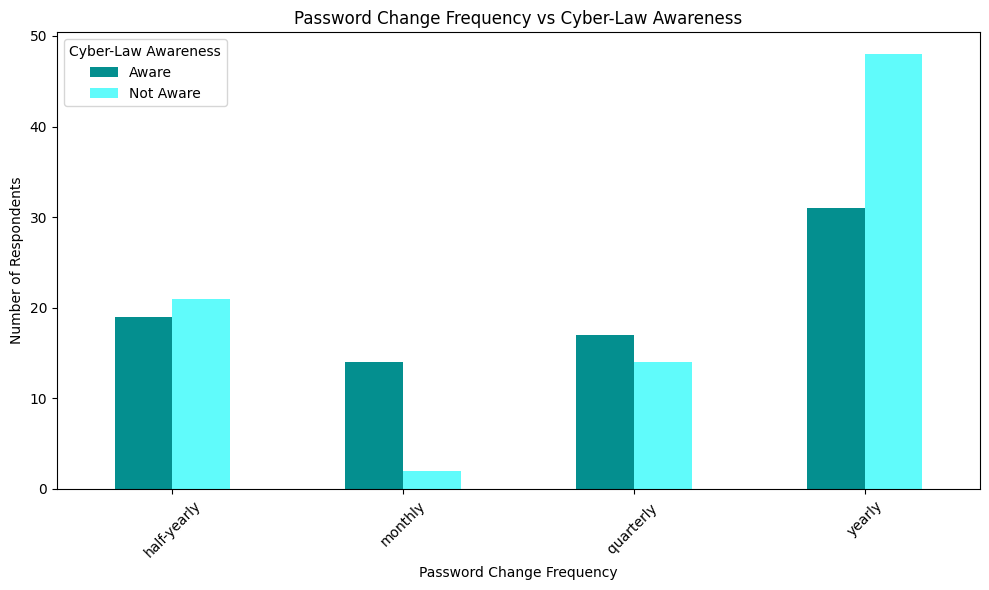

In [5]:
password_cyber = pd.crosstab(
    analysis.df["How Frequent!?"],
    analysis.df["Are you aware of cyber laws?!"].map({
        1: "Aware",
        0: "Not Aware"
    })
)

password_cyber.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#048F8F", "#60FBFB"]
)

plt.title("Password Change Frequency vs Cyber-Law Awareness")
plt.xlabel("Password Change Frequency")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Cyber-Law Awareness")

plt.tight_layout()
plt.show()

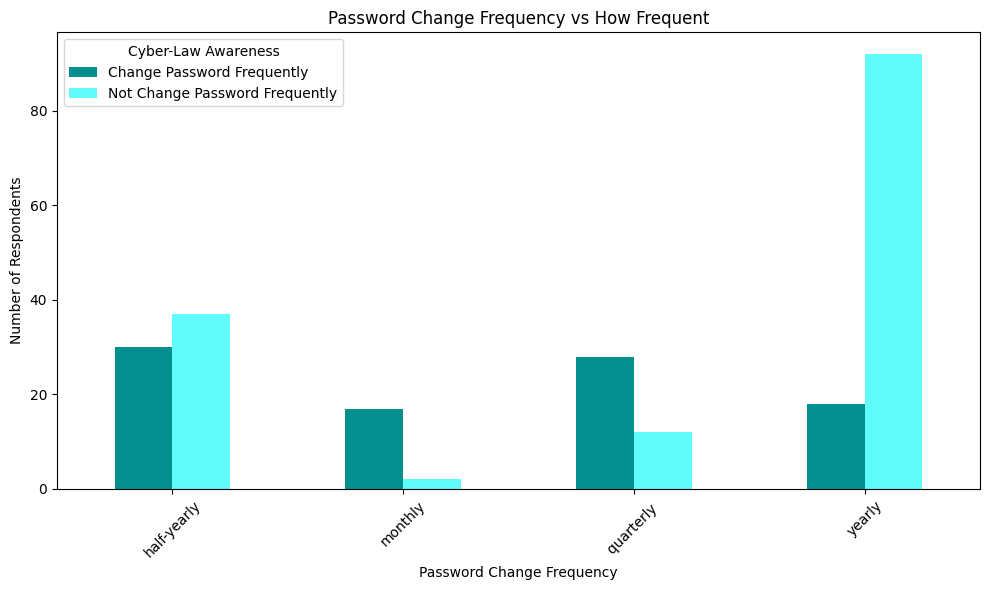

In [6]:
password_cyber = pd.crosstab(
    analysis.df["How Frequent!?"],
    analysis.df["Do you change your password Frequently?"].map({
        1: "Change Password Frequently",
        0: "Not Change Password Frequently"
    })
)

password_cyber.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#048F8F", "#60FBFB"]
)

plt.title("Password Change Frequency vs How Frequent")
plt.xlabel("Password Change Frequency")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=45)
plt.legend(title="Cyber-Law Awareness")

plt.tight_layout()
plt.show()


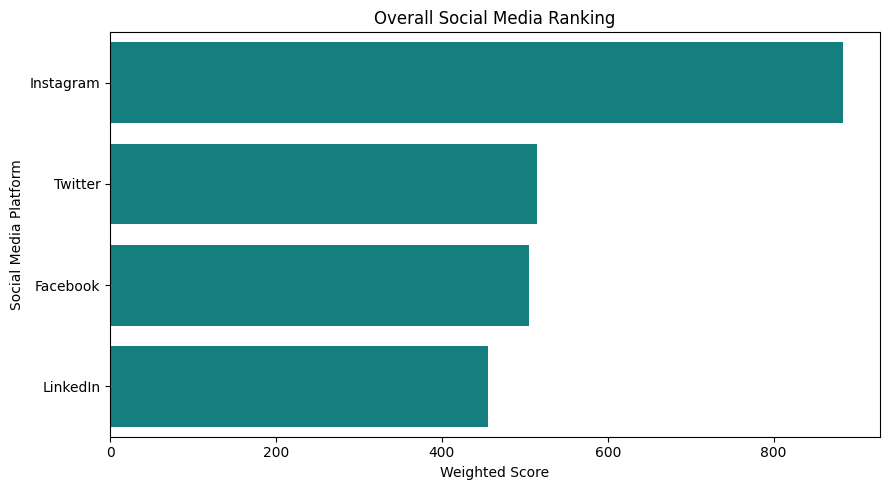

In [7]:
ranking = analysis.weighted_ranking()

plt.figure(figsize=(9, 5))

sns.barplot(
    data=ranking,
    x="Weighted Score",
    y="Social Media",
    color="#048F8F"
)

plt.title("Overall Social Media Ranking")
plt.xlabel("Weighted Score")
plt.ylabel("Social Media Platform")

plt.tight_layout()
plt.show()

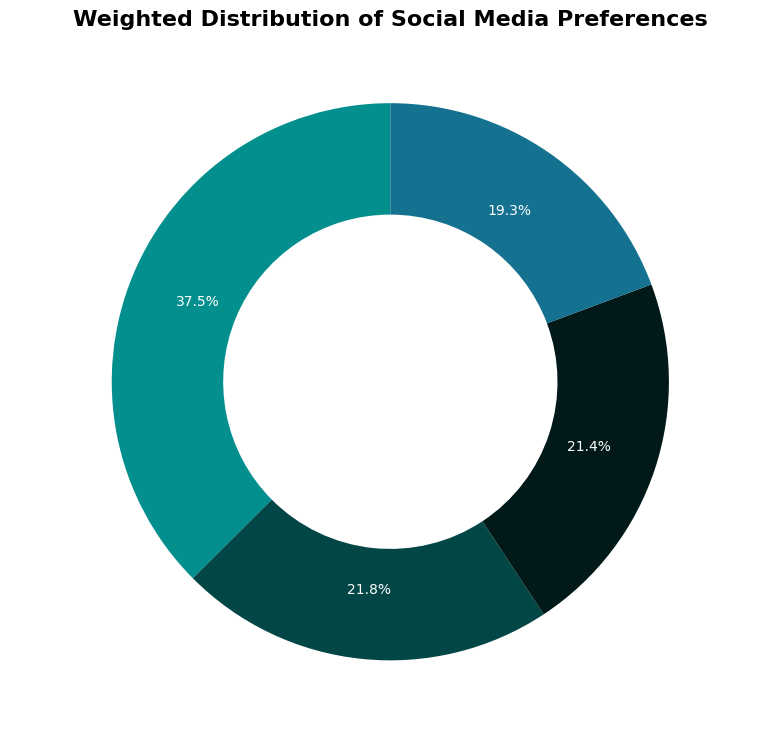

In [8]:
plt.figure(figsize=(8, 8))

wedges, texts, autotexts = plt.pie(
    ranking["Weighted Score"],
    labels=ranking["Social Media"],
    autopct="%1.1f%%",
    startangle=90,
    labeldistance=1.15,
    pctdistance=0.75,
    wedgeprops=dict(width=0.4),
    colors= ["#048F8F", "#024646", "#011919", "#147190"],
    textprops={"fontsize": 11, "color": "white"}
)

for text in texts:
    text.set_fontsize(12)

for autotext in autotexts:
    autotext.set_fontsize(10)
    
plt.title(
    "Weighted Distribution of Social Media Preferences",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

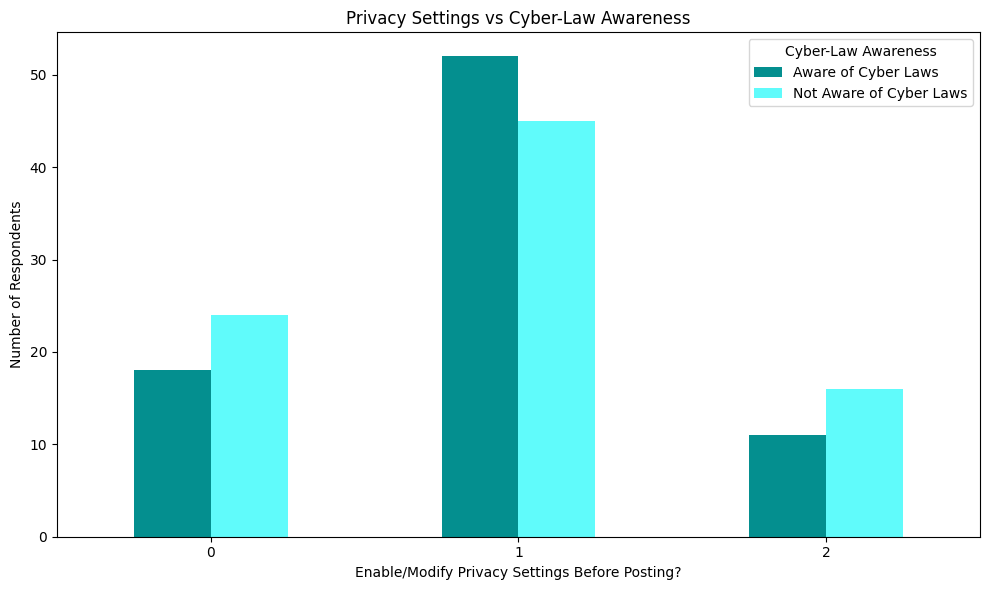

In [9]:
privacy_cyber = pd.crosstab(
    analysis.df[
        "Do you enable/modify privacy settings before you post any message?"
    ],
    analysis.df[
        "Are you aware of cyber laws?!"
    ].map({
        1: "Aware of Cyber Laws",
        0: "Not Aware of Cyber Laws"
    })
)


privacy_cyber.plot(
    kind="bar",
    figsize=(10, 6),
    color=["#048F8F", "#60FBFB"]
)


plt.title("Privacy Settings vs Cyber-Law Awareness")
plt.xlabel("Enable/Modify Privacy Settings Before Posting?")
plt.ylabel("Number of Respondents")
plt.xticks(rotation=0)
plt.legend(title="Cyber-Law Awareness")


plt.tight_layout()
plt.show()


In [10]:
import matplotlib.pyplot as plt

attack_counts = a.df["vector_class"].value_counts()

attack_counts = attack_counts[attack_counts.index.isin([
    "Human factor",
    "Technical"
])]

fig, ax = plt.subplots(figsize=(8, 8))

# Capture the values returned by pie()
wedges, texts, autotexts = ax.pie(
    attack_counts,
    labels=attack_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    pctdistance=0.75,
    colors=["#048F8F", "#024646"],
    wedgeprops={
        "width": 0.4,
        "edgecolor": "white"
    },
    textprops={
        "fontsize": 12
    }
)

# Make percentage text white
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight("bold")
    autotext.set_color("white")

# Title
ax.set_title(
    "Causation of Cyber Attacks",
    fontsize=16,
    fontweight="bold",
    pad=20
)

plt.tight_layout()
plt.show()

NameError: name 'a' is not defined

In [11]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Get the timeline data from your existing analysis object
timeline = a.lifecycle_timeline(
    subset="real",
    top_n=15,
    sort_by="date_occurred"
)

fig, ax = plt.subplots(figsize=(14, 8))

for i, row in timeline.iterrows():

    # Convert dates
    occurred = row["date_occurred"]
    discovered = row["date_discovered"]
    disclosed = row["date_disclosed"]

    # Draw exposure period
    if pd.notna(occurred) and pd.notna(discovered):
        ax.plot(
            [occurred, discovered],
            [i, i],
            color="#048F8F",
            linewidth=8,
            solid_capstyle="round"
        )

    # Draw notification period
    if pd.notna(discovered) and pd.notna(disclosed):
        ax.plot(
            [discovered, disclosed],
            [i, i],
            color="#F4A261",
            linewidth=8,
            solid_capstyle="round"
        )

    # Incident occurred
    if pd.notna(occurred):
        ax.scatter(
            occurred,
            i,
            color="#024646",
            s=80,
            zorder=3
        )

    # Incident discovered
    if pd.notna(discovered):
        ax.scatter(
            discovered,
            i,
            color="#E76F51",
            s=80,
            zorder=3
        )

    # Incident disclosed
    if pd.notna(disclosed):
        ax.scatter(
            disclosed,
            i,
            color="#C71585",
            s=80,
            zorder=3
        )

# Incident names on y-axis
ax.set_yticks(range(len(timeline)))
ax.set_yticklabels(timeline["label"])

# Date formatting
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))

plt.xticks(rotation=45)

# Labels
ax.set_xlabel("Date")
ax.set_ylabel("Organisation")

ax.set_title(
    "Cyber Incident Lifecycle",
    fontsize=18,
    fontweight="bold",
    pad=20
)

# Grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

# Legend
ax.scatter([], [], color="#024646", s=80, label="Incident occurred")
ax.scatter([], [], color="#E76F51", s=80, label="Incident discovered")
ax.scatter([], [], color="#C71585", s=80, label="Incident disclosed")

ax.legend(
    loc="upper right",
    frameon=False
)

plt.tight_layout()
plt.show()

NameError: name 'a' is not defined

In [14]:
organisation_counts = a.df["organisation"].value_counts()

print(organisation_counts[organisation_counts > 1])

organisation
Refuge Aid              42
Smith LLC               40
Jones Ltd               39
Lantern Appeal          38
Shelter Society         37
                        ..
Simpson-Brown            2
Mooreborough Council     2
Flynn and Sons           2
Graves Ltd               2
Griffiths Group          2
Name: count, Length: 2009, dtype: int64


Number of Refuge Aid incidents: 42
                                 incident_name date_occurred date_discovered date_disclosed
258          Unauthorised access at Refuge Aid    2019-01-23      2019-02-14     2019-02-20
1930                 Data breach at Refuge Aid    2019-07-12      2019-08-05     2019-08-06
2169                  Ransomware at Refuge Aid    2019-08-30      2019-08-30     2019-09-20
2307                 Data breach at Refuge Aid    2019-08-27      2019-09-13     2019-09-18
2690                 Data breach at Refuge Aid    2019-10-12      2019-10-19     2019-10-31
2845   Business email compromise at Refuge Aid    2019-10-13      2019-11-01     2020-01-01
3406           Phishing campaign at Refuge Aid    2019-09-29      2019-12-26     2020-01-01
3634                  Ransomware at Refuge Aid    2020-01-11      2020-01-17     2020-01-29
4489            Insider incident at Refuge Aid    2020-03-19      2020-04-09     2020-04-14
5123     Supply chain compromise at Refuge Ai

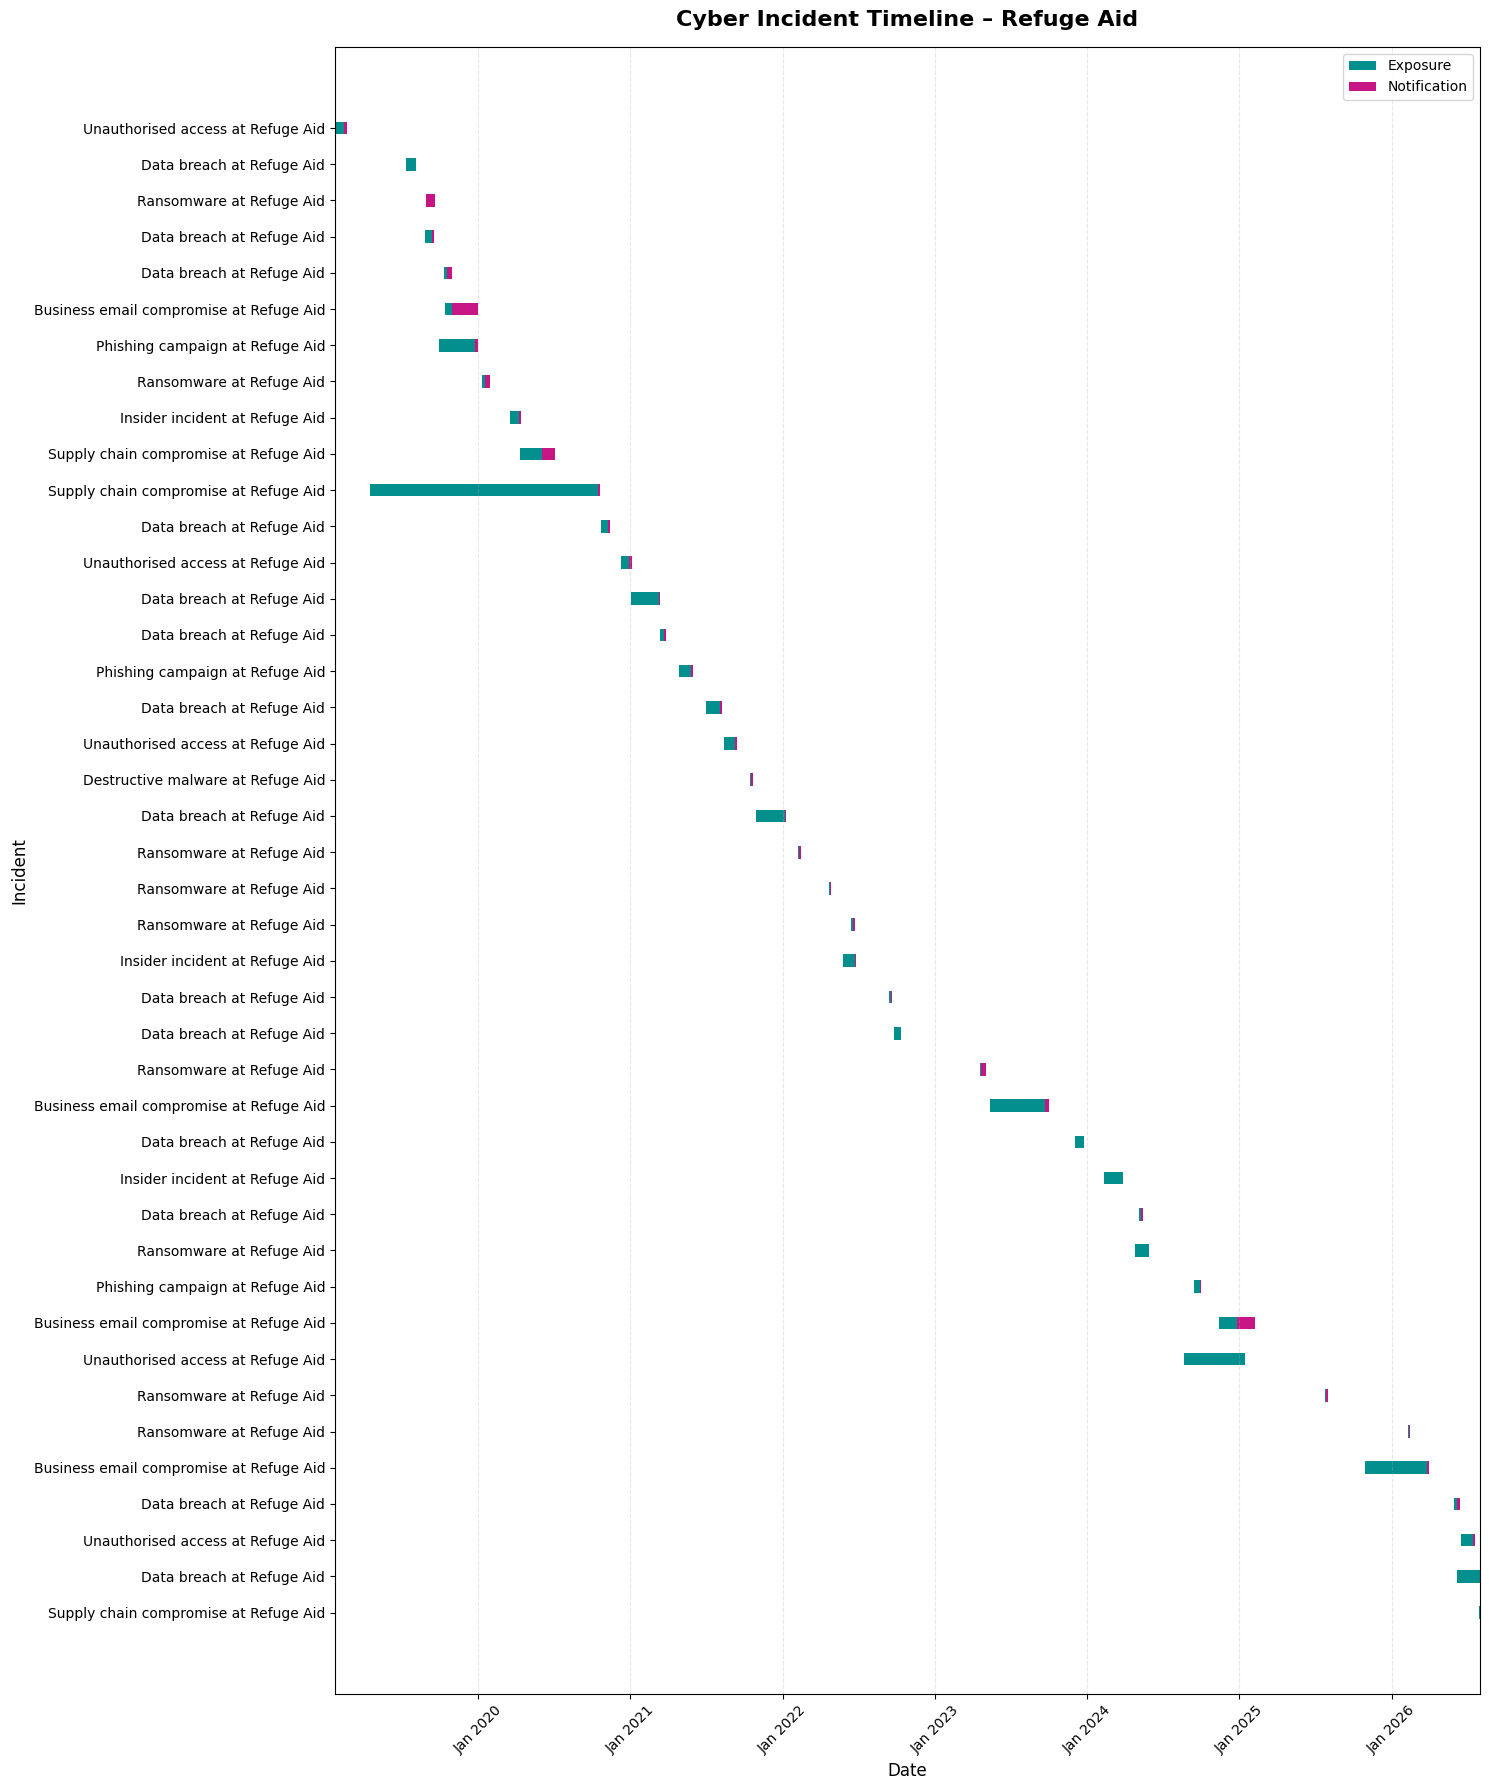

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------------------------------------
# 1. Get all incidents involving Refuge Aid
# -------------------------------------------------------

refuge_aid = a.df[
    a.df["organisation"].str.strip().str.lower() == "refuge aid"
].copy()

# Check what was found
print("Number of Refuge Aid incidents:", len(refuge_aid))
print(
    refuge_aid[
        ["incident_name", "date_occurred", "date_discovered", "date_disclosed"]
    ]
)


# -------------------------------------------------------
# 2. Create the Gantt chart
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(15, 18))

# Plot each incident
for i, (_, row) in enumerate(refuge_aid.iterrows()):

    # Dates
    occurred = row["date_occurred"]
    discovered = row["date_discovered"]
    disclosed = row["date_disclosed"]

    # Exposure period:
    # Incident occurred → Incident discovered
    if pd.notna(occurred) and pd.notna(discovered):

        ax.barh(
            i,
            discovered - occurred,
            left=occurred,
            height=0.35,
            color="#048F8F",
            label="Exposure" if i == 0 else ""
        )

    # Notification period:
    # Incident discovered → Incident disclosed
    if pd.notna(discovered) and pd.notna(disclosed):

        ax.barh(
            i,
            disclosed - discovered,
            left=discovered,
            height=0.35,
            color="#C71585",
            label="Notification" if i == 0 else ""
        )


# -------------------------------------------------------
# 3. Labels
# -------------------------------------------------------

ax.set_yticks(range(len(refuge_aid)))

ax.set_yticklabels(
    refuge_aid["incident_name"].str.slice(0, 40)
)

ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Incident", fontsize=12)

ax.set_title(
    "Cyber Incident Timeline – Refuge Aid",
    fontsize=16,
    fontweight="bold",
    pad=15
)


# -------------------------------------------------------
# 4. Make the date axis easier to read
# -------------------------------------------------------

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45)

# Put earliest incidents at the top
ax.invert_yaxis()

# Add grid
ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.3
)

ax.legend()

plt.tight_layout()
plt.show()


In [18]:
a.df[
    a.df["organisation"].str.contains(
        "Refuge",
        case=False,
        na=False
    )
]["organisation"].unique()


array(['Refuge Support', 'Refuge Alliance', 'Refuge Network',
       'Refuge Aid', 'Refuge Foundation', 'Refuge Trust', 'Refuge Care',
       'Refuge Fund', 'Refuge Appeal', 'Refuge Society'], dtype=object)

In [23]:
a.df["organisation"].value_counts().head(200)

organisation
Refuge Aid         42
Smith LLC          40
Jones Ltd          39
Lantern Appeal     38
Shelter Society    37
                   ..
Hill and Sons      10
Wilson Ltd         10
Lewis PLC          10
Walker LLC         10
Garcia PLC         10
Name: count, Length: 200, dtype: int64

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# -------------------------------------------------------
# Find all incidents for Wellbeing Society
# -------------------------------------------------------

hill_and_sons = a.df[
    a.df["organisation"].str.strip().str.lower() == "hill and sons"
].copy()

# Sort by date occurred
hill_and_sons = hill_and_sons.sort_values("date_occurred").reset_index(drop=True)

print("Number of incidents:", len(hill_and_sons))

print(
    hill_and_sons[
        [
            "incident_name",
            "date_occurred",
            "date_discovered",
            "date_disclosed"
        ]
    ].to_string(index=False)
)

start_date = pd.to_datetime("2025-01-01")
end_date = pd.to_datetime("2025-5-30")

hill_and_sons_2025 = hill_and_sons[
    (hill_and_sons["date_occurred"] >= start_date) &
    (hill_and_sons["date_occurred"] <= end_date)
].copy()


# -------------------------------------------------------
# Create Gantt chart
# -------------------------------------------------------

fig, ax = plt.subplots(figsize=(13, 6))

for i, row in hill_and_sons_2025.iterrows():

    occurred = row["date_occurred"]
    discovered = row["date_discovered"]
    disclosed = row["date_disclosed"]

    # Occurred → Discovered
    if pd.notna(occurred) and pd.notna(discovered):

        ax.barh(
            i,
            discovered - occurred,
            left=occurred,
            height=0.45,
            color="#048F8F",
            label="Occurred → Discovered" if i == 0 else ""
        )

    # Discovered → Disclosed
    if pd.notna(discovered) and pd.notna(disclosed):

        ax.barh(
            i,
            disclosed - discovered,
            left=discovered,
            height=0.45,
            color="#C71585",
            label="Discovered → Disclosed" if i == 0 else ""
        )

    # Mark when the incident occurred
    if pd.notna(occurred):
        ax.scatter(
            occurred,
            i,
            color="#024646",
            s=50,
            zorder=3
        )

    # Mark when it was discovered
    if pd.notna(discovered):
        ax.scatter(
            discovered,
            i,
            color="#F4A261",
            s=50,
            zorder=3
        )

    # Mark when it was disclosed
    if pd.notna(disclosed):
        ax.scatter(
            disclosed,
            i,
            color="#C71585",
            s=50,
            zorder=3
        )


# -------------------------------------------------------
# Y-axis
# -------------------------------------------------------

ax.set_yticks(range(len(hill_and_sons_2025)))

ax.set_yticklabels(
    hill_and_sons_2025
    ["incident_name"].str.slice(0, 45)
)

ax.invert_yaxis()


# -------------------------------------------------------
# X-axis – make dates readable
# -------------------------------------------------------

ax.xaxis.set_major_locator(mdates.AutoDateLocator())
ax.xaxis.set_major_formatter(
    mdates.DateFormatter("%b %Y")
)

plt.xticks(rotation=45, ha="right")


# -------------------------------------------------------
# Labels and title
# -------------------------------------------------------

ax.set_xlabel(
    "Date",
    fontsize=12
)

ax.set_ylabel(
    "Incident",
    fontsize=12
)

ax.set_title(
    "Cyber Incident Lifecycle – Hill and Sons",
    fontsize=17,
    fontweight="bold",
    pad=15
)


# -------------------------------------------------------
# Grid and legend
# -------------------------------------------------------

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.75
)

ax.legend(
    loc="upper right"
)

plt.tight_layout()
plt.show()

NameError: name 'a' is not defined

In [28]:
import pandas as pd

# Make sure the dates are datetime
a.df["date_occurred"] = pd.to_datetime(a.df["date_occurred"], errors="coerce")
a.df["date_disclosed"] = pd.to_datetime(a.df["date_disclosed"], errors="coerce")

# Group incidents by organisation
organisation_summary = (
    a.df
    .dropna(subset=["date_occurred", "date_disclosed"])
    .groupby("organisation")
    .agg(
        incidents=("incident_id", "count"),
        earliest_occurred=("date_occurred", "min"),
        latest_disclosed=("date_disclosed", "max")
    )
)

# Calculate how many days the organisation's incidents span
organisation_summary["date_span_days"] = (
    organisation_summary["latest_disclosed"]
    - organisation_summary["earliest_occurred"]
).dt.days

# Only consider organisations with at least 3 incidents
good_organisations = organisation_summary[
    organisation_summary["incidents"] >= 3
].copy()

# Sort by shortest date span
good_organisations = good_organisations.sort_values(
    "date_span_days"
)

print(good_organisations.head(100))

                        incidents earliest_occurred latest_disclosed  date_span_days
organisation                                                                        
Johnsonmouth Authority          3        2019-12-25       2020-02-10              47
Davis-Mitchell                  3        2023-12-24       2024-03-24              91
Bailey PLC                      3        2020-05-19       2020-09-30             134
Simpson and Sons                3        2019-06-07       2019-12-04             180
Hamilton LLC                    3        2023-12-03       2024-08-01             242
...                           ...               ...              ...             ...
Clarke-Smith                    3        2021-04-09       2023-09-10             884
Simmons PLC                     3        2022-11-24       2025-04-28             886
Duncan PLC                      3        2022-02-18       2024-07-31             894
Gill and Sons                   3        2020-09-07       2023-03